In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import networkx as nx
from tqdm.notebook import tqdm, trange

In [4]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

In [20]:
step = 0.05
n = 500
low_bound, up_bound = 0, 10

In [21]:
cs = np.linspace(low_bound, up_bound, num=int(up_bound / 0.05) + 1)
cs

array([ 0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,
        0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,  0.8 ,  0.85,
        0.9 ,  0.95,  1.  ,  1.05,  1.1 ,  1.15,  1.2 ,  1.25,  1.3 ,
        1.35,  1.4 ,  1.45,  1.5 ,  1.55,  1.6 ,  1.65,  1.7 ,  1.75,
        1.8 ,  1.85,  1.9 ,  1.95,  2.  ,  2.05,  2.1 ,  2.15,  2.2 ,
        2.25,  2.3 ,  2.35,  2.4 ,  2.45,  2.5 ,  2.55,  2.6 ,  2.65,
        2.7 ,  2.75,  2.8 ,  2.85,  2.9 ,  2.95,  3.  ,  3.05,  3.1 ,
        3.15,  3.2 ,  3.25,  3.3 ,  3.35,  3.4 ,  3.45,  3.5 ,  3.55,
        3.6 ,  3.65,  3.7 ,  3.75,  3.8 ,  3.85,  3.9 ,  3.95,  4.  ,
        4.05,  4.1 ,  4.15,  4.2 ,  4.25,  4.3 ,  4.35,  4.4 ,  4.45,
        4.5 ,  4.55,  4.6 ,  4.65,  4.7 ,  4.75,  4.8 ,  4.85,  4.9 ,
        4.95,  5.  ,  5.05,  5.1 ,  5.15,  5.2 ,  5.25,  5.3 ,  5.35,
        5.4 ,  5.45,  5.5 ,  5.55,  5.6 ,  5.65,  5.7 ,  5.75,  5.8 ,
        5.85,  5.9 ,  5.95,  6.  ,  6.05,  6.1 ,  6.15,  6.2 ,  6.25,
        6.3 ,  6.35,

In [22]:
ps = cs / (n - 1)

Text(0, 0.5, 'isolated probability')

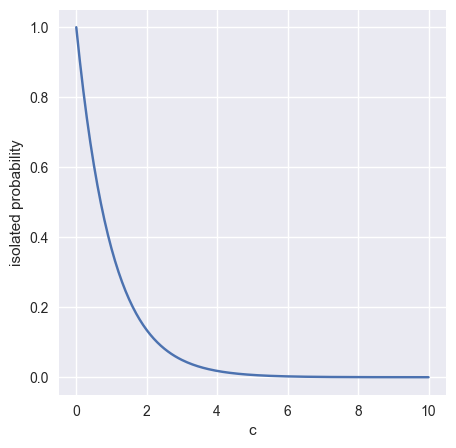

In [23]:
fig = plt.figure(figsize=(5, 5))

ax = fig.add_subplot(111)
ax.plot(cs, (1-ps)**(n - 1))
ax.set_xlabel('c')
ax.set_ylabel('isolated probability')

In [24]:
p_isolated = pd.Series((1-ps)**(n - 1))

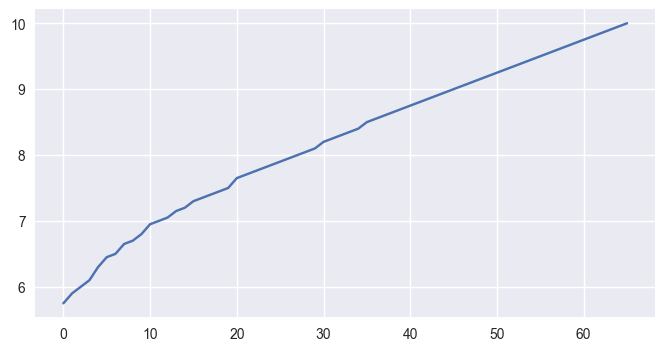

In [57]:
c_connected = []
# for _ in trange(100):
for c in cs:
    p = c / (n - 1)
    g = nx.erdos_renyi_graph(n, p)

    if nx.is_connected(g):
        # print(f"is_connected at c = {c}")
        c_connected.append(c)
        # break

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)
ax.plot(c_connected)


In [58]:
np.min(c_connected)

5.75

In [59]:
5.75 / (n - 1)

0.011523046092184368

In [60]:
np.log(n) / n

0.012429216196844383

In [ ]:
np.min(c_connected)

In [31]:
c_connected = np.array(c_connected)
p_connected = c_connected / (n - 1)

np.mean(p_connected)

0.010587174348697397

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

Text(0.5, 1.0, 'Different c values and probability of node being isolated and mean of ')

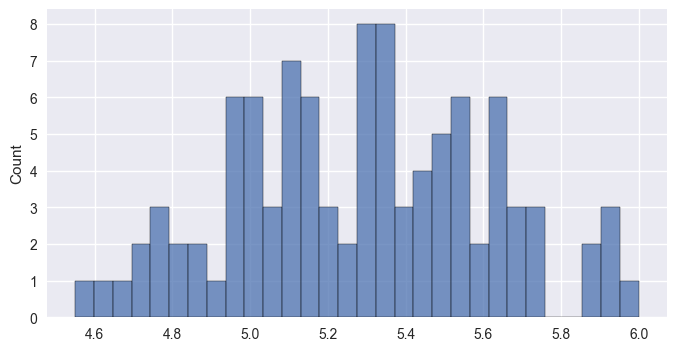

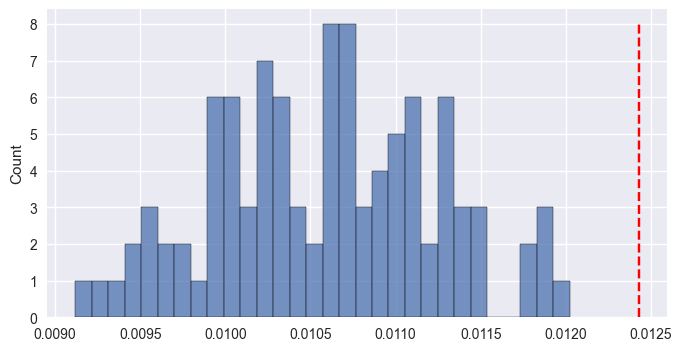

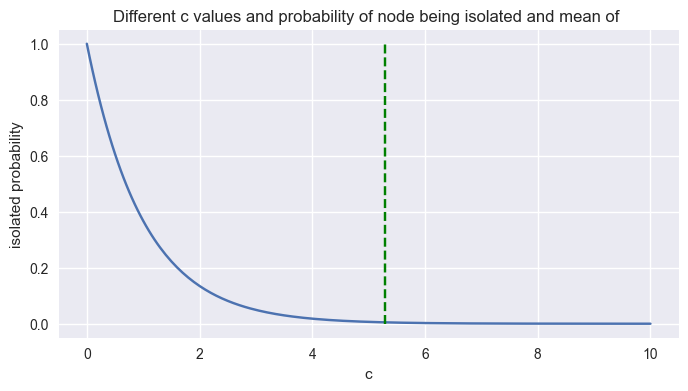

In [38]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)
sns.histplot(c_connected, ax=ax, bins=30)
# ax.set_title('Smallest p values with which G(n, p) is connected')

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)
sns.histplot(p_connected, ax=ax, bins=30)
ax.vlines([np.log(n)/n], ymin=0, ymax=8, linestyles='dashed', colors='red')

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)
ax.plot(cs, (1-ps)**(n - 1))
ax.set_xlabel('c')
ax.set_ylabel('isolated probability')
ax.vlines([np.mean(c_connected)], ymin=0, ymax=1, linestyles='dashed', colors='green')
ax.set_title("Different c values and probability of node being isolated and mean of ")